<a href="https://colab.research.google.com/github/devarahaasan/forest-cover-classification/blob/main/project3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EcoType: Forest Cover Type Prediction Using Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read the data using Pandas

In [ ]:
data = pd.read_csv('/content/cover_type (1).csv')


In [ ]:
data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29


Understanding the Data

In [ ]:
data.shape

(145890, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()*100/len(data)

np.float64(0.0)

In [ ]:
data.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
data['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [ ]:
data['Cover_Type'].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


In [ ]:
data['Cover_Type'].unique()

array(['Aspen', 'Lodgepole Pine', 'Spruce/Fir', 'Krummholz',
       'Ponderosa Pine', 'Douglas-fir', 'Cottonwood/Willow'], dtype=object)

In [ ]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
for col in data.columns:
  print(f"{col}:\n Unique values:",data[col].nunique(),"\n", data[col].unique())
  print()
  print()

Elevation:
 Unique values: 1665 
 [2596 2590 2804 ... 3504 3510 3604]


Aspect:
 Unique values: 361 
 [ 51  56 139 155  45 132  49  59 201 151 134 214 157 259  72   0  38  71
 209 114  54  22 135 163 148 117 122 105 102  23  41 125  92  98 354 347
 346 330 128  68  94  99  66 100 323  79  81 315  74  11  42  75 107  90
  40  63  13  80 166   6  30 118 160 326 153 143 352  14 358 332  18 306
 173  31 164  34  84 170 211  32  57 348 333 324  88 111  53  58  76  17
 124 119 320 112  83   1  37 356 307   7  12 344 228 284 299 220   2  95
 289  21  20 200 349 328 221 257 276 196 189 130 357  15   8 288 129  28
  86 292 115  29 180 116  46 256 338 127 319  89  43 188  50 138 312   9
  10  36 167 260 187 279 245  27 359  16  48 149  60  77 230 152  70 325
 126 222 109  85  25 176 144 175 162  73  39  78 331 329 355  87 285 108
 106  24  52 261 232 246 342  61 141 216 236 254 336 278  62 237 281  69
 251 150 185 110 103 243 215 238 317 252 136 131 133 123 120 351 202 194
 101 282 258 270  65 2

Handling Outliers

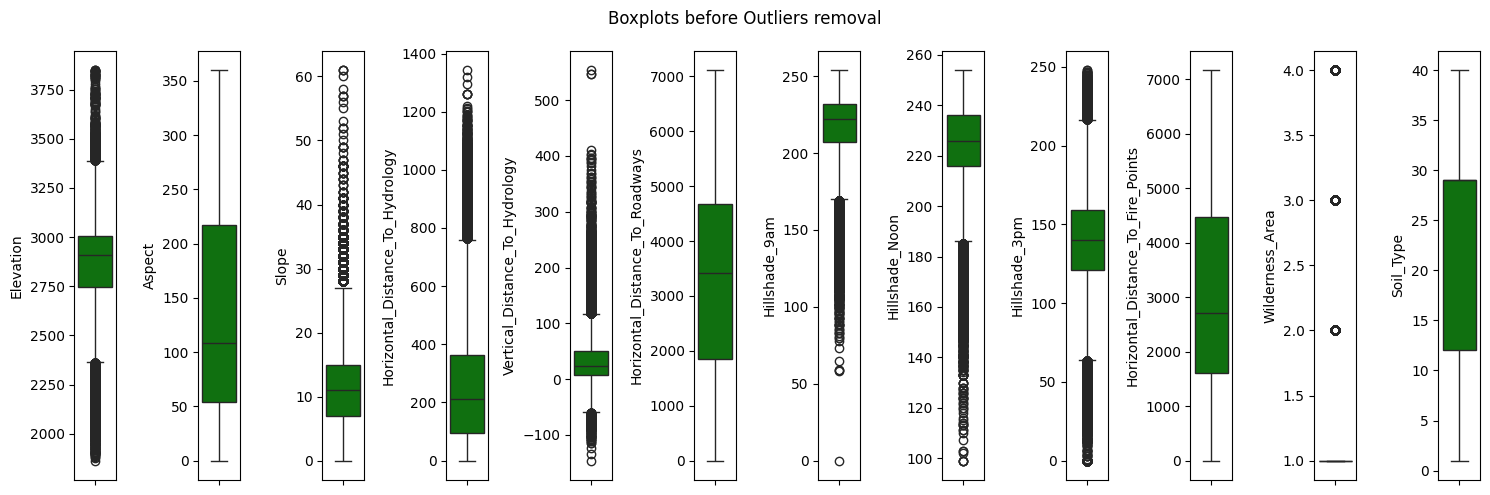

In [ ]:
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points','Wilderness_Area',
       'Soil_Type']

# Loop through numerical columns and create boxplots

plt.figure(figsize=(15, 5))
plt.suptitle("Boxplots before Outliers removal")

for i in range(0, len(numerical_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=data[numerical_cols[i]],color='green')
    plt.tight_layout()

IQR Method

In [ ]:
# value =percentile/100(n+1)

In [ ]:
len(data)

145890

In [ ]:
(25/100)*(145890+1)

36472.75

In [ ]:
data['Elevation'].sort_values().reset_index().iloc[36473]

,36473
index,142055
Elevation,2747


In [ ]:
data['Elevation'].sort_values().reset_index()

,index,Elevation
0,2234,1863
1,2215,1874
2,2214,1879
3,2233,1888
4,2186,1889
...,...,...
145885,9724,3846
145886,9723,3846
145887,9726,3848
145888,14562,3849


In [ ]:
(75/100)*(145890+1)

109418.25

In [ ]:
data['Elevation'].sort_values().reset_index().iloc[109418]

,109418
index,67247
Elevation,3004


In [ ]:
q1=2747
q3=3004
# iqr=q3-q1
iqr=257

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
print(lower,upper)

2361.5 3389.5


In [ ]:
data['Elevation'].quantile(0.25)

np.float64(2747.0)

In [ ]:
data['Elevation'].quantile(0.75)

np.float64(3004.0)

In [ ]:
for col in numerical_cols:

    Q1 = data[col].quantile(0.25)  # 25th percentile
    Q3 = data[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range

    # Define lower and upper bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at lower and upper bound
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

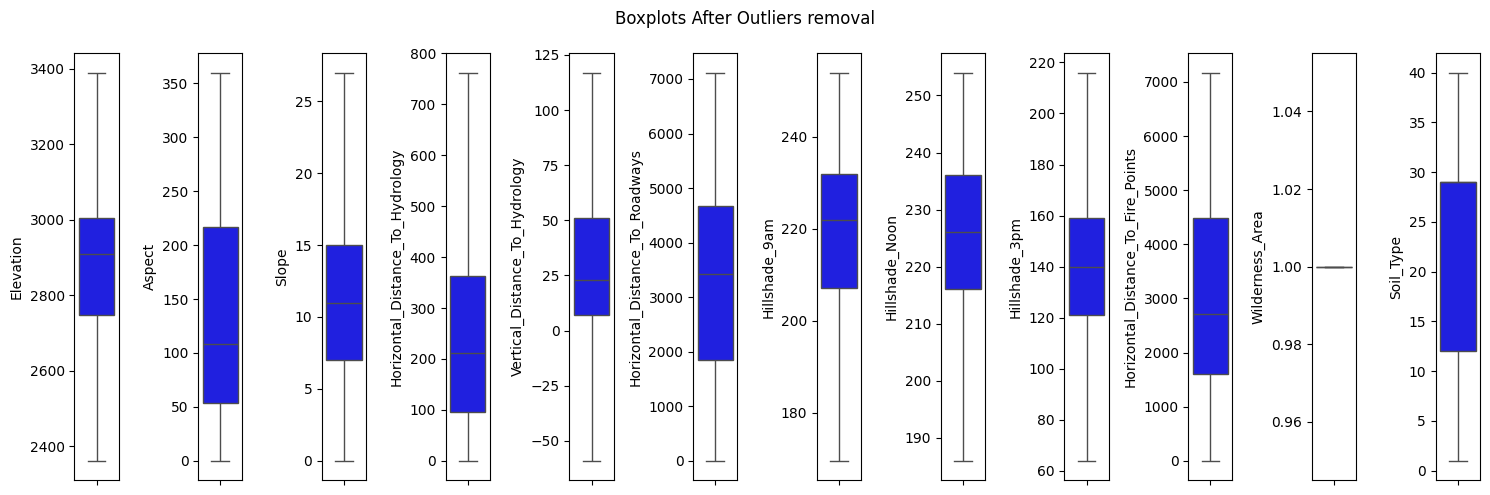

In [ ]:
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points','Wilderness_Area',
       'Soil_Type']

# Loop through numerical columns and create boxplots

plt.figure(figsize=(15, 5))
plt.suptitle("Boxplots After Outliers removal")
for i in range(0, len(numerical_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=data[numerical_cols[i]],color='blue')
    plt.tight_layout()

EDA

In [ ]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
data['Cover_Type'].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


CATEGORICAL VARIABLE ANALYSIS

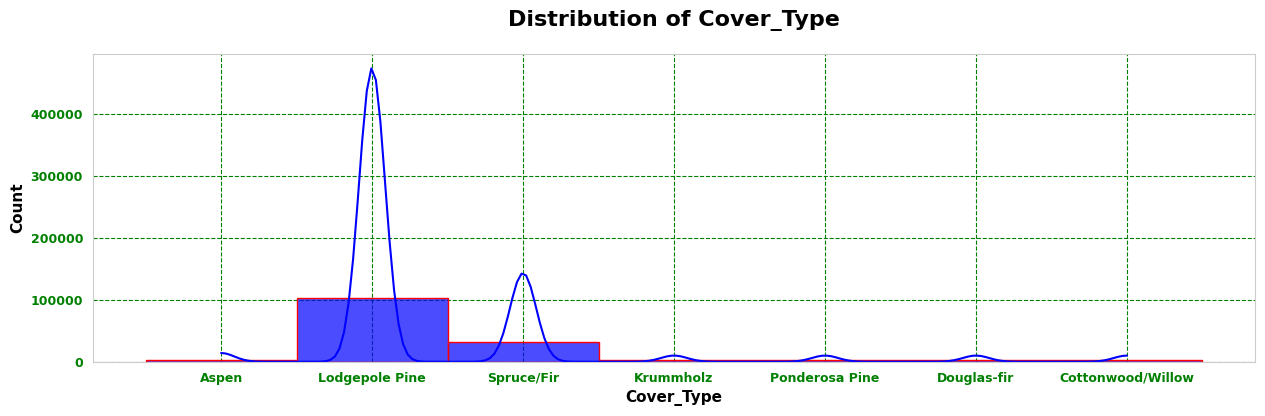

In [ ]:
plt.figure(figsize=(15, 4))
sns.set_style("whitegrid", {
    "grid.color": "green",
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

sns.histplot(data=data, x='Cover_Type',
             bins=10,
             kde=True,
             color='blue',
             edgecolor='red',
             alpha=0.7)
plt.title('Distribution of Cover_Type',
          fontsize=16,
          fontweight='bold',
          color='black',
          pad=20)
plt.xlabel('Cover_Type', fontsize=11, color='black',fontweight='bold')
plt.ylabel('Count', fontsize=11, color='black', fontweight='bold')
plt.yticks(fontsize=9 ,color='green',fontweight='bold')
plt.xticks(fontsize=9, color='green',fontweight='bold')
plt.show()


1️⃣ Highly Imbalanced Distribution

The dataset is strongly imbalanced.

Lodgepole Pine has an extremely high count compared to all other cover types.

This suggests the dataset is dominated by one forest type.

📌 Insight:
Models trained on this dataset may become biased toward predicting Lodgepole Pine unless techniques like class balancing or weighting are applied.

2️⃣ Second Most Common Forest Type

Spruce/Fir appears as the second largest class.

However, its count is still far lower than Lodgepole Pine.

📌 Insight:
Although present in good numbers, it is still significantly underrepresented relative to Lodgepole Pine.

3️⃣ Rare Cover Types

The following forest types appear very rarely:

Aspen

Krummholz

Ponderosa Pine

Douglas-fir

Cottonwood/Willow

📌 Insight:
These classes may suffer from poor predictive performance in machine learning models due to low sample sizes.

4️⃣ Long-Tail Distribution

The distribution follows a long-tail pattern:

Few classes have very high counts

Several classes have very low counts

📌 Insight:
This indicates ecological dominance of certain forest types in the region.

5️⃣ Implication for Modeling

Important preprocessing considerations:

Use class weighting

Apply SMOTE / oversampling

Evaluate with F1-score or balanced accuracy, not just accuracy

📌 Reason: Accuracy alone will be misleading due to the imbalance.

NUMERICAL VARIABLE ANALYSIS

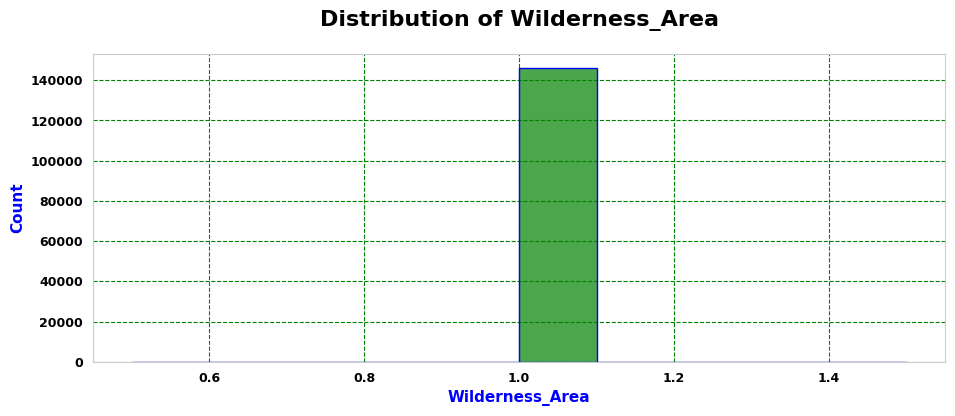

In [ ]:
plt.figure(figsize=(11, 4))
sns.set_style("whitegrid", {
    "grid.color": "green",
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

sns.histplot(data=data, x='Wilderness_Area',
             bins=10,
             kde=True,
             color='green',
             edgecolor='blue',
             alpha=0.7)
plt.title('Distribution of Wilderness_Area',
          fontsize=16,
          fontweight='bold',
          color='black',
          pad=20)
plt.xlabel('Wilderness_Area', fontsize=11, color='blue',fontweight='bold')
plt.ylabel('Count', fontsize=11, color='blue', fontweight='bold')
plt.yticks(fontsize=9 ,color='black',fontweight='bold')
plt.xticks(fontsize=9, color='black',fontweight='bold')
plt.show()


1️⃣ Single Category Dominance

The plot shows that most observations fall into one wilderness area category.

📌 Insight:
This indicates a highly skewed distribution, where one wilderness area contributes the majority of the data points.

2️⃣ Potential Data Encoding

Wilderness_Area in the Forest CoverType dataset is typically one-hot encoded into four variables.
Your visualization suggests that the data may have been aggregated or represented as a single encoded value.

📌 Insight:
The concentration around value ≈ 1 may indicate that many records belong to the same wilderness area.

3️⃣ Lack of Variability

Since the distribution is concentrated in one region, the feature might have limited variability in the plotted form.

📌 Insight:
Low variability can reduce the predictive power of this feature unless it is analyzed in its original categorical/one-hot format.

4️⃣ Possible Data Representation Issue

A histogram may not be the best visualization for this feature if it represents categorical wilderness areas (1–4).

📌 Better approach:
Use a count plot or bar chart to clearly show the number of samples in each wilderness area.

5️⃣ Modeling Implication

If one wilderness area dominates:

The model may learn patterns mainly from that area

Minority wilderness areas may have lower prediction accuracy

📌 Recommendation:
Check class balance across wilderness areas.

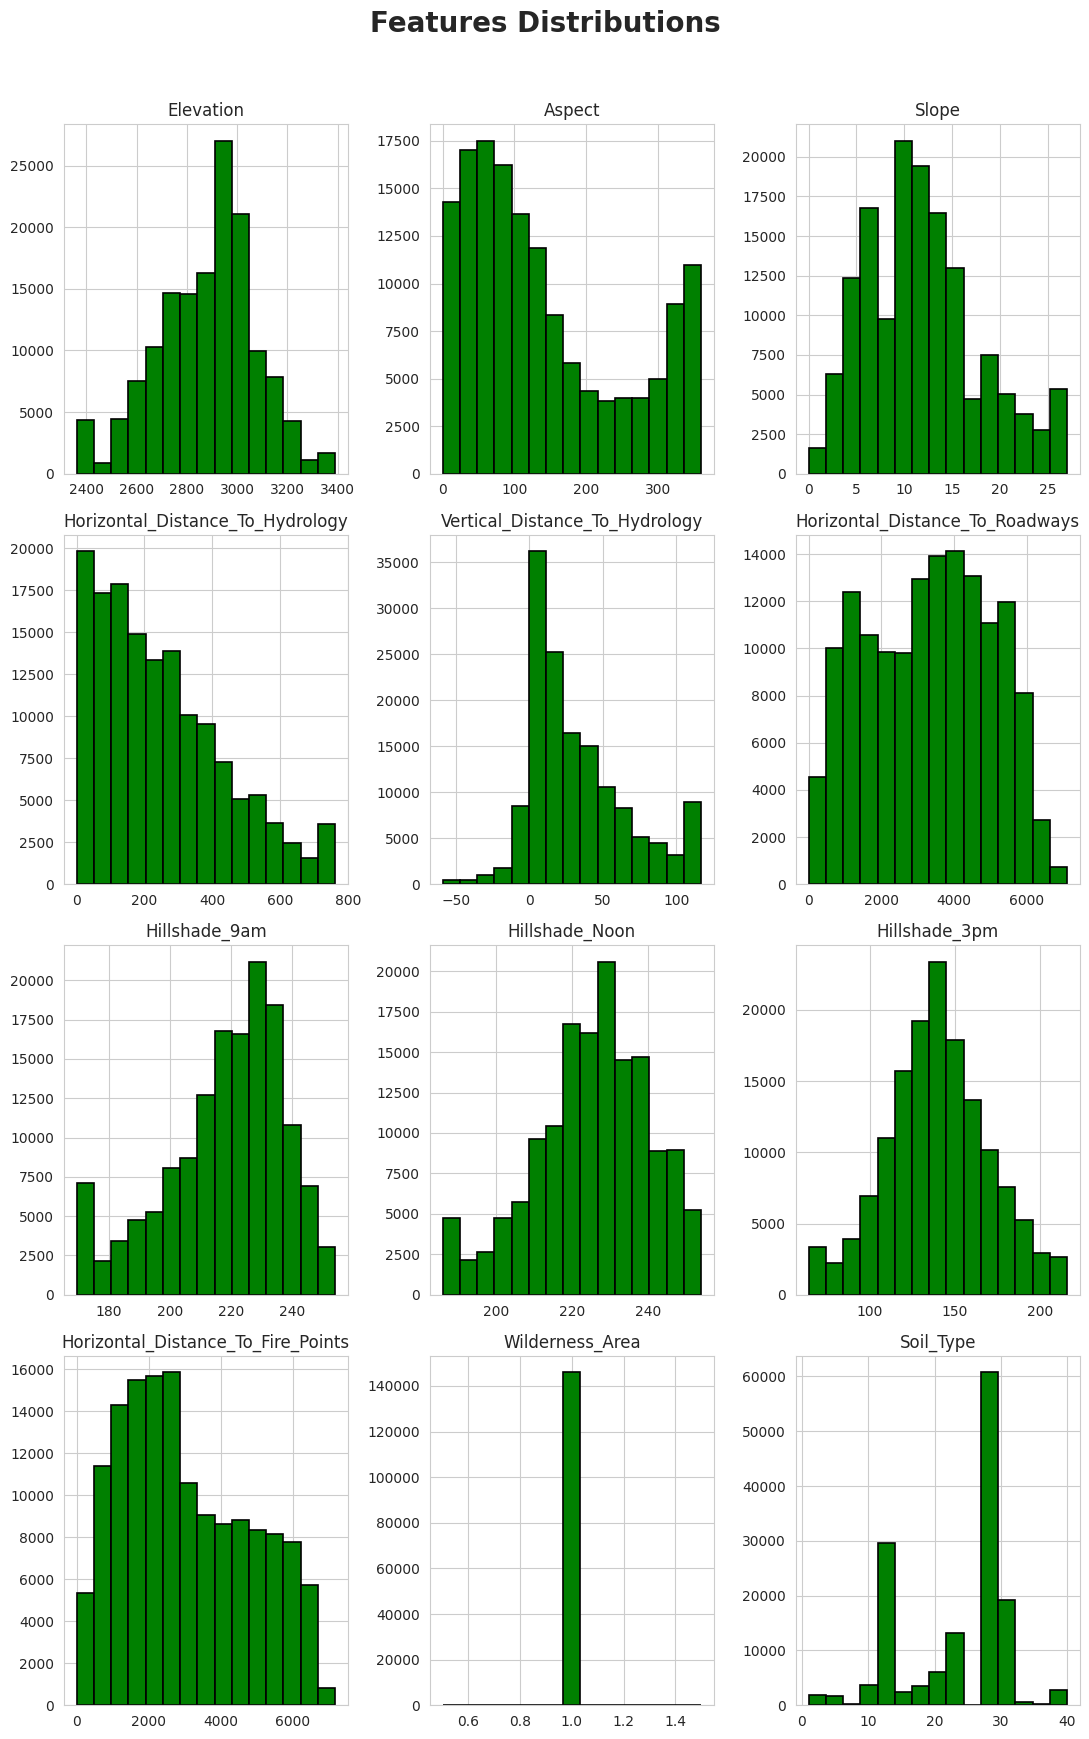

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

data[numerical_cols].hist(
                        figsize=(11,17),
                        bins=15,
                        color="green",   # bar color
                        edgecolor="black",
                        linewidth=1.2
)

plt.suptitle("Features Distributions", fontsize=20, fontweight="bold",y=1.02)

plt.tight_layout()

plt.show()


1️⃣ Elevation is Concentrated in a Narrow Range

Most elevation values lie between 2700–3100 meters.

Very few points exist outside this range.

📌 Insight:
The dataset represents high-altitude forest regions, suggesting Elevation is likely a key factor in predicting forest cover type.

2️⃣ Aspect Shows Nearly Uniform Distribution

Values spread across 0–360°.

📌 Insight:
Slope direction varies widely across the dataset, meaning forests exist on slopes facing all directions, affecting sunlight exposure and vegetation growth.

3️⃣ Moderate Slopes Dominate

Most slope values fall between 5° and 15°.

📌 Insight:
The terrain is moderately sloped, which supports stable vegetation growth compared to steep slopes.

4️⃣ Most Areas are Close to Water

Horizontal Distance to Hydrology

Many observations are within 0–400 meters.

📌 Insight:
Forest locations tend to be relatively close to water sources, which is an important environmental factor for vegetation.

5️⃣ Vertical Distance to Hydrology Centers Around Zero

Most values are near 0.

📌 Insight:
Many locations are at similar elevation levels as nearby water bodies, meaning they are neither significantly above nor below them.

6️⃣ Road Accessibility Varies Widely

Horizontal Distance to Roadways

Ranges from 0 to ~7000 meters.

📌 Insight:
Some forest areas are close to roads, while others are very remote, indicating different levels of human influence.

7️⃣ Hillshade Variables Show Normal Distribution

Hillshade at 9am, Noon, and 3pm follow bell-shaped patterns.

📌 Insight:
Sunlight intensity across the terrain follows natural patterns, which affects vegetation growth and forest types.

8️⃣ Distance to Fire Points Mostly Moderate

Most values fall between 1000–5000 meters.

📌 Insight:
Many forest locations are moderately distant from fire ignition points, which may influence fire risk and vegetation distribution.

9️⃣ Wilderness Area Feature is Highly Skewed

Most observations belong to one wilderness area.

📌 Insight:
The dataset may be dominated by one geographical region, which could introduce bias in modeling.

🔟 Soil Type Distribution is Uneven

Some soil types appear very frequently, while others are rare.

📌 Insight:
Soil diversity exists, but a few soil types dominate the dataset, which may strongly influence forest cover type.

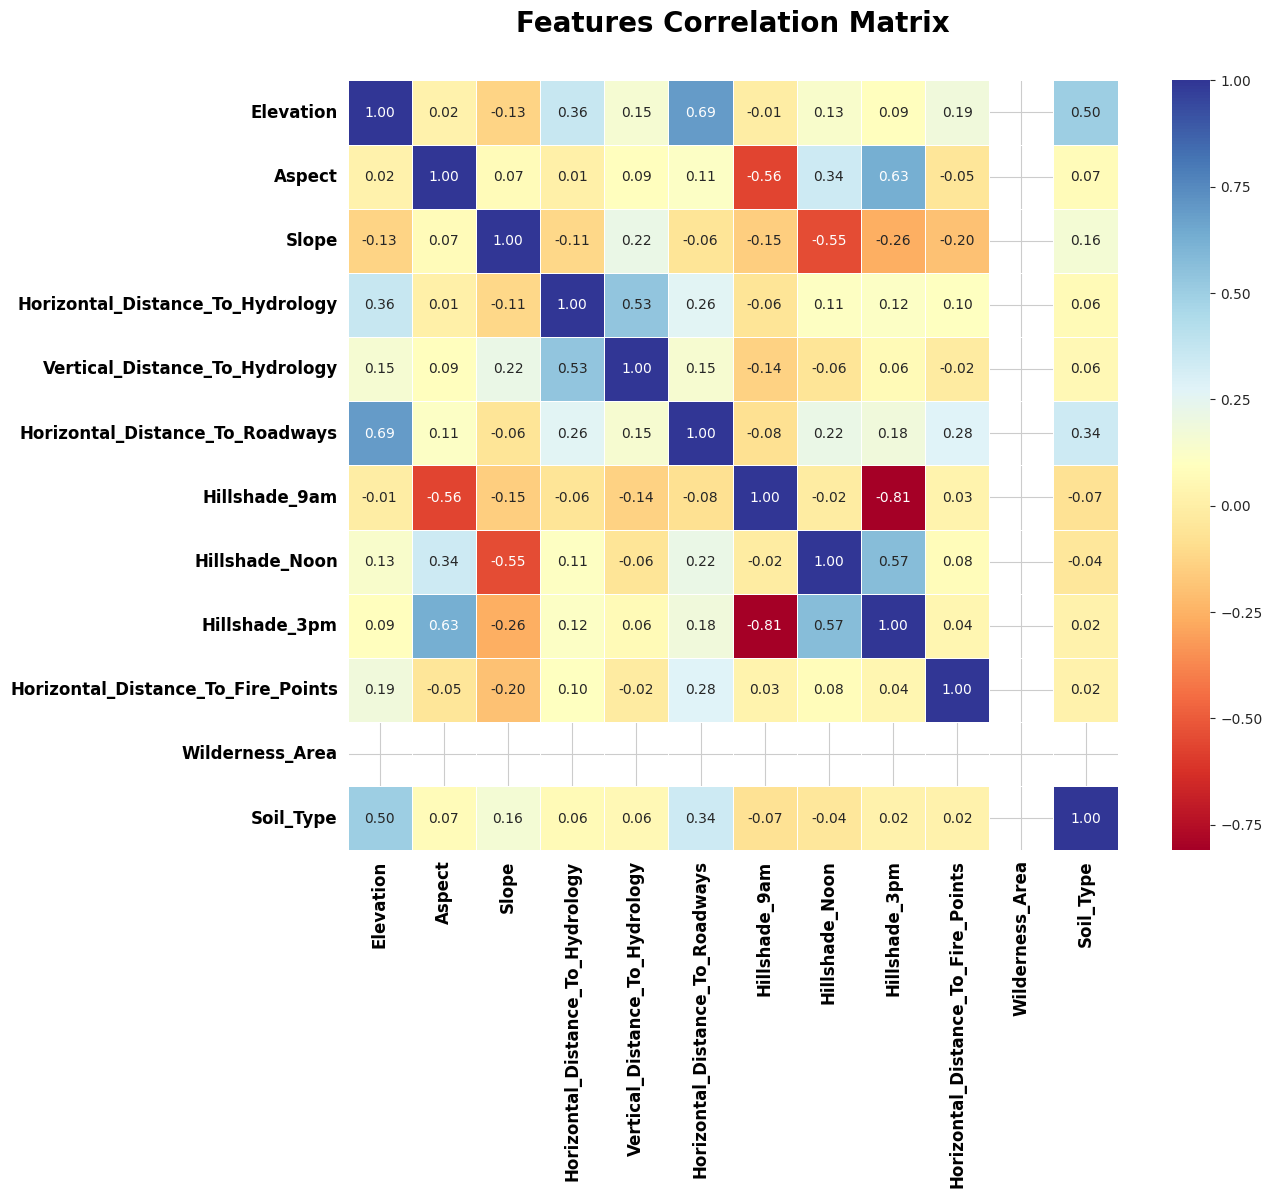

In [ ]:
plt.figure(figsize=(14,10))

corr =data[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Features Correlation Matrix",color='black', fontsize=20,fontweight='bold',pad=35)
plt.yticks(fontsize=12 ,color='black',fontweight='bold')
plt.xticks(fontsize=12, color='black',fontweight='bold')
plt.show()


1️⃣ Strong Positive Correlation: Elevation & Distance to Roadways

Elevation ↔ Horizontal_Distance_To_Roadways = 0.69

📌 Insight:
Higher elevation areas tend to be farther from roadways, meaning remote mountainous regions are less accessible.

2️⃣ Strong Negative Correlation: Hillshade 9am & Hillshade 3pm

Hillshade_9am ↔ Hillshade_3pm = -0.81

📌 Insight:
Areas receiving strong sunlight in the morning receive less in the afternoon, due to slope direction and terrain orientation.

3️⃣ Moderate Correlation Between Hydrology Distances

Horizontal_Distance_To_Hydrology ↔ Vertical_Distance_To_Hydrology = 0.53

📌 Insight:
Locations farther from water horizontally also tend to have greater vertical differences from water sources.

4️⃣ Elevation Influences Hydrology Distance

Elevation ↔ Horizontal_Distance_To_Hydrology = 0.36

📌 Insight:
Higher elevation areas tend to be farther from water bodies, which is common in mountainous terrain.

5️⃣ Aspect Strongly Affects Sunlight

Aspect ↔ Hillshade_3pm = 0.63

Aspect ↔ Hillshade_9am = -0.56

📌 Insight:
Slope direction significantly influences sunlight exposure at different times of the day.

6️⃣ Slope Negatively Correlated with Hillshade Noon

Slope ↔ Hillshade_Noon = -0.55

📌 Insight:
Steeper slopes tend to receive less direct sunlight at noon, likely due to terrain angle.

7️⃣ Soil Type Moderately Correlated with Elevation

Soil_Type ↔ Elevation = 0.50

📌 Insight:
Certain soil types are more common at specific elevation levels, indicating environmental dependence.

8️⃣ Most Other Features Show Weak Correlation

Most correlations are between -0.3 and 0.3.

📌 Insight:
Features are relatively independent, which is beneficial for machine learning models because it reduces multicollinearity.

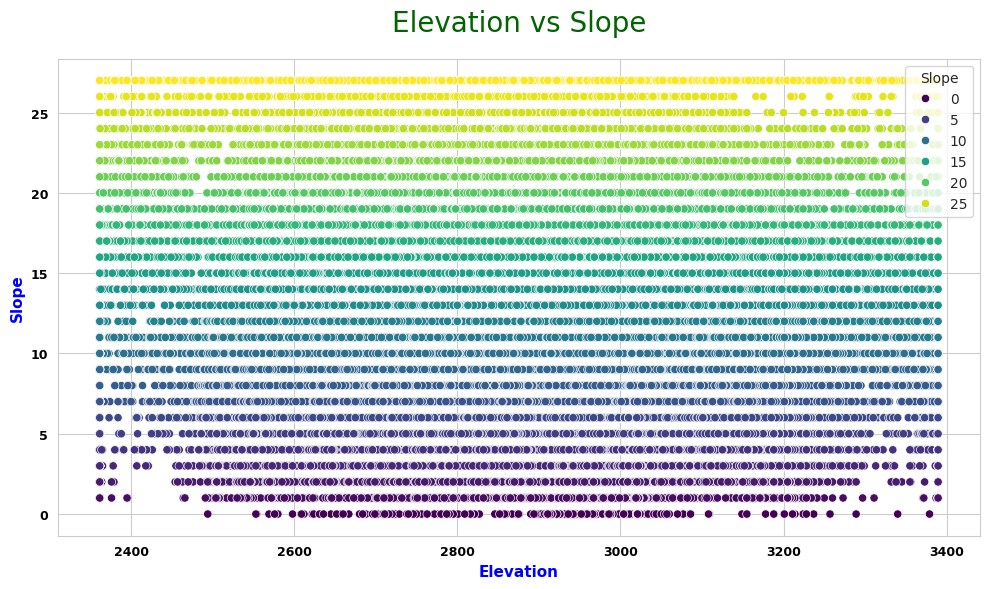

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Elevation",
    y="Slope",
    data=data,
    hue="Slope",
    palette="viridis",
    legend=True
)

plt.title("Elevation vs Slope", fontsize=20, color="darkgreen",pad=20)


plt.xlabel('Elevation',fontsize=11, color='blue',fontweight='bold')
plt.ylabel('Slope', fontsize=11, color='blue', fontweight='bold')
plt.yticks(fontsize=9 ,color='black',fontweight='bold')
plt.xticks(fontsize=9, color='black',fontweight='bold')
plt.tight_layout()
plt.show()



1️⃣ Weak Relationship Between Elevation and Slope

Points are spread across all elevation values for almost every slope level.

📌 Insight:
There is no strong correlation between elevation and slope, meaning steep and gentle slopes occur at all elevation levels.

2️⃣ Elevation Range of the Dataset

Most elevations lie between 2500 and 3200 meters.

📌 Insight:
The forest areas in the dataset are mainly mid-to-high elevation mountainous regions.

3️⃣ Slope Distribution Pattern

Most slope values fall between 5° and 20°.

📌 Insight:
The terrain is generally moderately sloped, which supports vegetation growth and forest cover.

4️⃣ Extreme Slopes Are Rare

Slopes above 25° appear less frequently.

📌 Insight:
Very steep terrain is less common, suggesting forests are mostly located on manageable slopes.

5️⃣ Even Terrain Variation

Slopes are distributed evenly across the elevation range.

📌 Insight:
Elevation alone does not determine terrain steepness in this dataset.

 Feature Engineering

In [ ]:
data['Distance_to_Hydrology'] = (data['Horizontal_Distance_To_Hydrology']**2 + data['Vertical_Distance_To_Hydrology']**2)**0.5
data['Average_Hillshade'] = (data['Hillshade_9am'] + data['Hillshade_Noon'] + data['Hillshade_3pm']) / 3
data['Hydro_Road_Total'] = data['Horizontal_Distance_To_Hydrology'] + data['Horizontal_Distance_To_Roadways']
data['Hydro_Fire_Total'] = data['Horizontal_Distance_To_Hydrology'] + data['Horizontal_Distance_To_Fire_Points']
data['Road_Fire_Total'] = data['Horizontal_Distance_To_Roadways'] + data['Horizontal_Distance_To_Fire_Points']
data['Hydro_Road_Diff'] = abs(data['Horizontal_Distance_To_Hydrology'] - data['Horizontal_Distance_To_Roadways'])
data['Elevation_Vertical_Hydro'] = data['Elevation'] - data['Vertical_Distance_To_Hydrology']
data['Slope_Elevation_Interaction'] = data['Slope'] * data['Elevation']
data['Hillshade_9am_Noon_Diff'] = data['Hillshade_9am'] - data['Hillshade_Noon']
data['Hillshade_Noon_3pm_Diff'] = data['Hillshade_Noon'] - data['Hillshade_3pm']

In [ ]:
data.columns


Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Hydro_Road_Total', 'Hydro_Fire_Total', 'Road_Fire_Total',
       'Hydro_Road_Diff', 'Elevation_Vertical_Hydro',
       'Slope_Elevation_Interaction', 'Hillshade_9am_Noon_Diff',
       'Hillshade_Noon_3pm_Diff'],
      dtype='object')

In [ ]:
data.shape

(145890, 23)

In [ ]:
data.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Distance_to_Hydrology,Average_Hillshade,Hydro_Road_Total,Hydro_Fire_Total,Road_Fire_Total,Hydro_Road_Diff,Elevation_Vertical_Hydro,Slope_Elevation_Interaction,Hillshade_9am_Noon_Diff,Hillshade_Noon_3pm_Diff
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,258.000000,200.333333,768.0,6537.0,6789.0,252.0,2596.0,7788.0,-11.0,84.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,212.084889,202.000000,602.0,6437.0,6615.0,178.0,2596.0,5180.0,-15.0,84.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,275.769832,202.333333,3448.0,6389.0,9301.0,2912.0,2739.0,25236.0,-4.0,103.0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,...,268.799182,199.333333,3332.0,6453.0,9301.0,2848.0,2668.0,50130.0,0.0,116.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,153.003268,201.333333,544.0,6325.0,6563.0,238.0,2596.0,5190.0,-14.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834.0,88.0,8.0,376.0,44.0,2552.0,232.0,227.0,128.0,1595.0,...,378.565714,195.666667,2928.0,1971.0,4147.0,2176.0,2790.0,22672.0,5.0,99.0
145886,2832.0,68.0,4.0,390.0,44.0,2522.0,224.0,231.0,142.0,1572.0,...,392.474203,199.000000,2912.0,1962.0,4094.0,2132.0,2788.0,11328.0,-7.0,89.0
145887,2829.0,80.0,7.0,390.0,33.0,2492.0,229.0,228.0,133.0,1550.0,...,391.393664,196.666667,2882.0,1940.0,4042.0,2102.0,2796.0,19803.0,1.0,95.0
145888,2826.0,121.0,7.0,379.0,30.0,2462.0,232.0,234.0,135.0,1528.0,...,380.185481,200.333333,2841.0,1907.0,3990.0,2083.0,2796.0,19782.0,-2.0,99.0


In [ ]:
feature_engg_numeric_columns=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Hydro_Road_Total', 'Hydro_Fire_Total', 'Road_Fire_Total',
       'Hydro_Road_Diff', 'Elevation_Vertical_Hydro',
       'Slope_Elevation_Interaction', 'Hillshade_9am_Noon_Diff',
       'Hillshade_Noon_3pm_Diff']

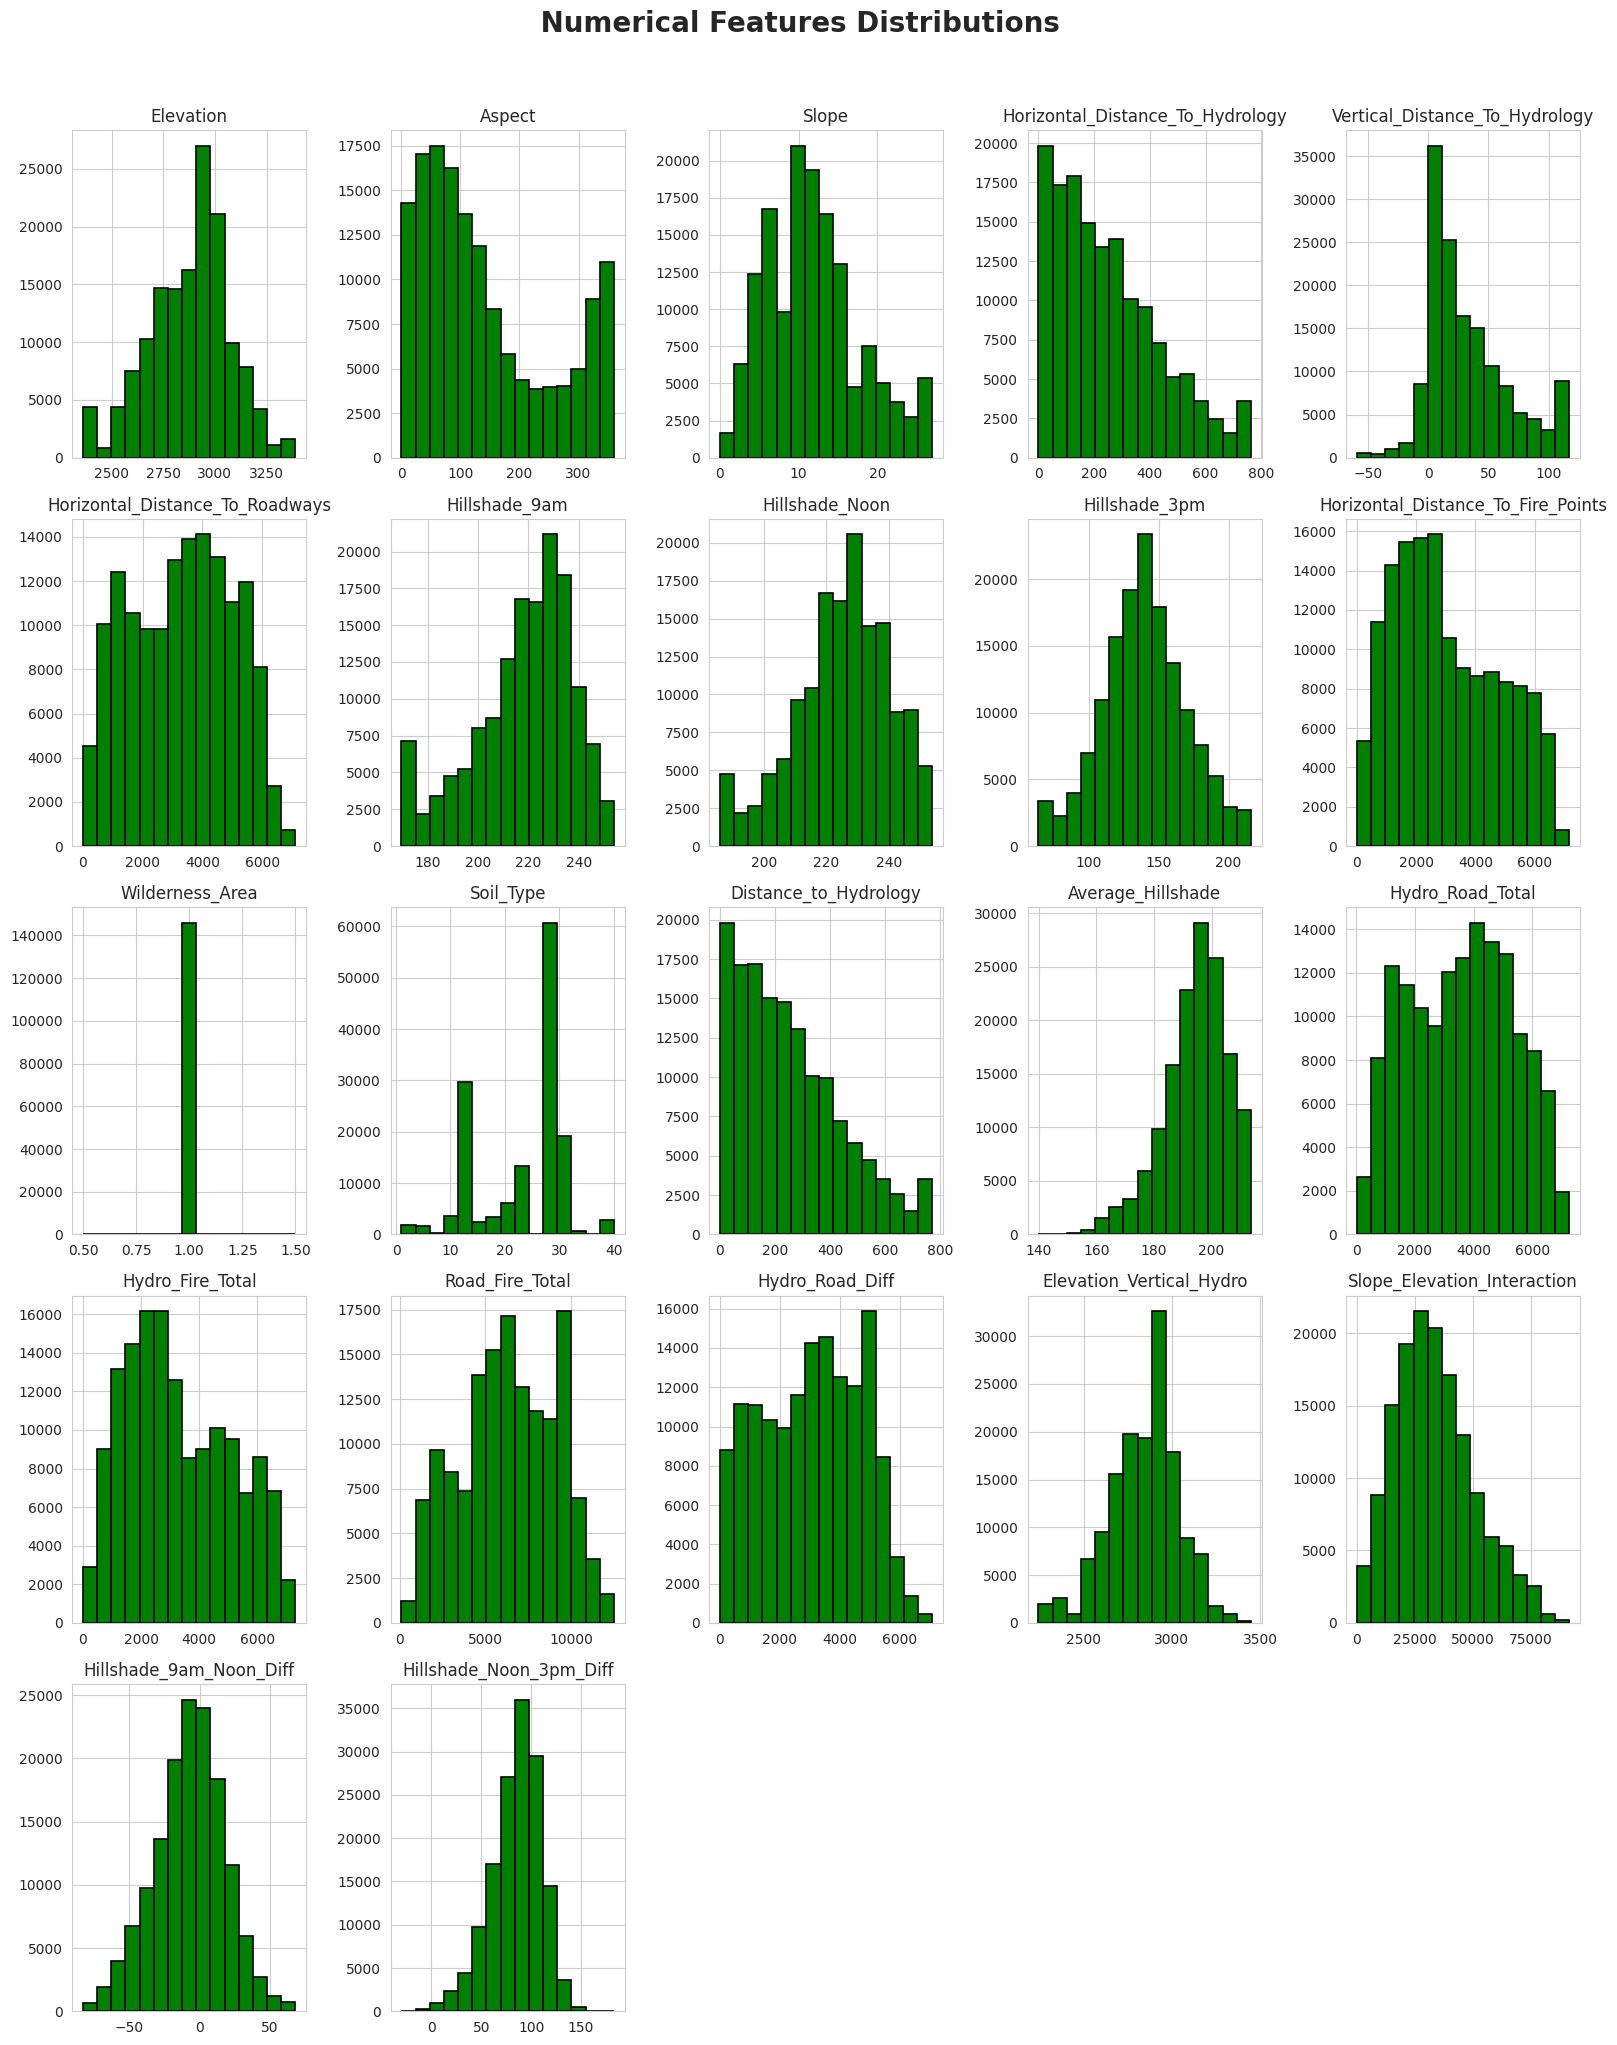

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

data[feature_engg_numeric_columns].hist(
                        figsize=(16,20),
                        bins=15,
                        color="green",   # bar color
                        edgecolor="black",
                        linewidth=1.2
)

plt.suptitle(" Numerical Features Distributions", fontsize=20, fontweight="bold",y=1.02)

plt.tight_layout()

plt.show()

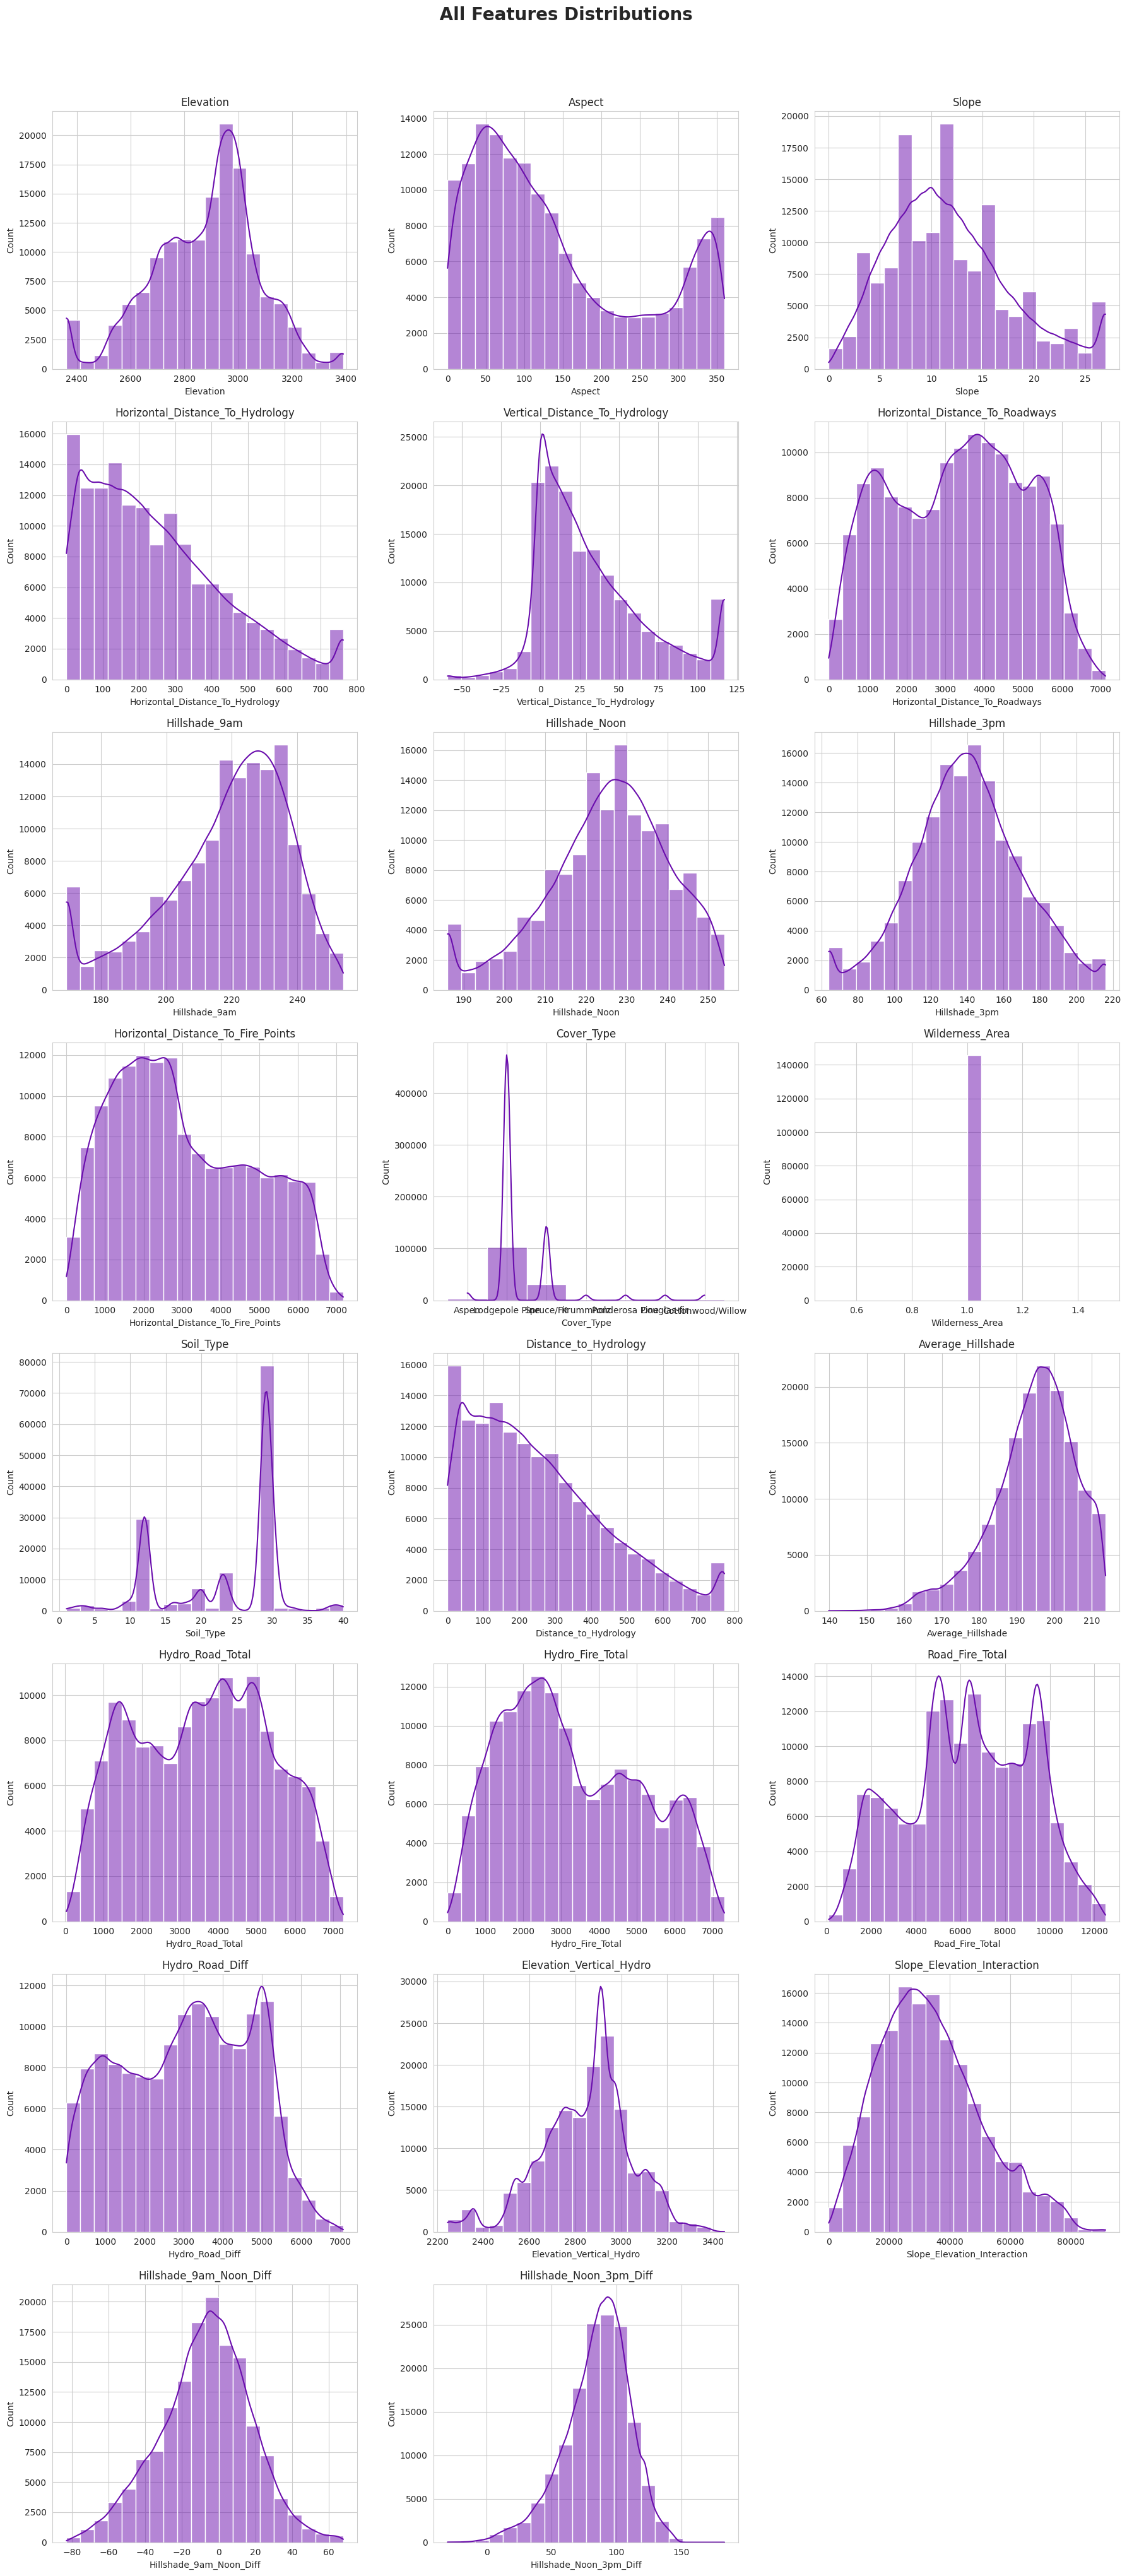

In [ ]:


# List of columns
cols = data.columns

# Number of columns in each row
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col], bins=20, kde=True, color="#6A0DAD")
    plt.title(col)
sns.set_theme(style="darkgrid", palette="deep")
plt.suptitle(" All Features Distributions", fontsize=20, fontweight="bold",y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Distance_to_Hydrology,Average_Hillshade,Hydro_Road_Total,Hydro_Fire_Total,Road_Fire_Total,Hydro_Road_Diff,Elevation_Vertical_Hydro,Slope_Elevation_Interaction,Hillshade_9am_Noon_Diff,Hillshade_Noon_3pm_Diff
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,258.000000,200.333333,768.0,6537.0,6789.0,252.0,2596.0,7788.0,-11.0,84.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,212.084889,202.000000,602.0,6437.0,6615.0,178.0,2596.0,5180.0,-15.0,84.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,275.769832,202.333333,3448.0,6389.0,9301.0,2912.0,2739.0,25236.0,-4.0,103.0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,...,268.799182,199.333333,3332.0,6453.0,9301.0,2848.0,2668.0,50130.0,0.0,116.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,153.003268,201.333333,544.0,6325.0,6563.0,238.0,2596.0,5190.0,-14.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834.0,88.0,8.0,376.0,44.0,2552.0,232.0,227.0,128.0,1595.0,...,378.565714,195.666667,2928.0,1971.0,4147.0,2176.0,2790.0,22672.0,5.0,99.0
145886,2832.0,68.0,4.0,390.0,44.0,2522.0,224.0,231.0,142.0,1572.0,...,392.474203,199.000000,2912.0,1962.0,4094.0,2132.0,2788.0,11328.0,-7.0,89.0
145887,2829.0,80.0,7.0,390.0,33.0,2492.0,229.0,228.0,133.0,1550.0,...,391.393664,196.666667,2882.0,1940.0,4042.0,2102.0,2796.0,19803.0,1.0,95.0
145888,2826.0,121.0,7.0,379.0,30.0,2462.0,232.0,234.0,135.0,1528.0,...,380.185481,200.333333,2841.0,1907.0,3990.0,2083.0,2796.0,19782.0,-2.0,99.0


In [ ]:
data.to_csv("cleaned_data.csv",index = False)

In [ ]:
import pickle

In [ ]:
with open('my_data1.pkl', 'wb') as file:
    pickle.dump(data, file)

print("data saved succesfully")

data saved succesfully
